# 卷积神经网络

本节以计算机视觉任务为例，介绍卷积神经网络（CNN）

计算机视觉是让机器理解图像的学科，主要包含：
* 图像/视频分类
* 图像/视频分割
* 目标检测
* 目标跟踪
* 图像/视频理解（对一副图像生成一段描述）
* 等
  
应用：
* 相机和照片应用程序使用计算机视觉来增强和整理图像
* 现代汽车使用计算机视觉来避免与其他车辆相撞并保持在车道线内行驶
* 制造商使用计算机视觉来识别各种产品的缺陷
* 安防摄像头使用计算机视觉来检测潜在的入侵者

本质上，任何可以用视觉方式描述的东西都可能是一个计算机视觉问题。

本节主要覆盖内容：
| **主题** | **内容** |
| --- | --- |
| **0. PyTorch 中的计算机视觉库** | PyTorch 有许多内置的计算机视觉库，让我们来看看它们。 |
| **1. 加载数据** | 为了练习计算机视觉，我们将从CIFAR10数据库开始开始，加载一些不同的类别的图像。 |
| **2. 准备数据** | 我们有一些图像，让我们用 [PyTorch `DataLoader`](https://pytorch.org/docs/stable/data.html) 将它们加载进来，以便在训练循环中使用。 |
| **3. 模型 0：构建基准模型** | 在这里，我们将创建一个多类分类模型来学习数据中的模式，我们还将选择一个 **loss function**、**optimizer** 并构建一个 **training loop**。 |
| **4. 使用模型 0 进行预测和评估** | 用基准模型进行一些预测并评估它们。 |
| **5. 为后续模型设置设备无关代码** | 编写设备无关代码是一种最佳实践。 |
| **6. 模型 1：添加非线性层** | 实验是机器学习的重要组成部分，尝试通过添加非线性层来改进我们的基准模型。 |
| **7. 模型 2：卷积神经网络（CNN）** | 引入强大的卷积神经网络架构了，这是计算机视觉领域的经典架构。 |
| **8. 比较我们的模型** | 我们已经构建了三个不同的模型，比较它们。 |
| **9. 评估最佳模型** | 在随机图像上进行一些预测并评估我们的最佳模型。 |
| **10. 生成混淆矩阵** | 混淆矩阵是评估分类模型的好方法，让我们看看如何生成。 |
| **11. 保存和加载最佳模型** | 由于可能希望以后使用我们的模型，保存并确保它能够正确加载回来。 |

## 0. PyTorch 中的计算机视觉库

在开始编写代码之前，我们先了解一下 PyTorch 中一些常用的计算机视觉库。

| PyTorch 模块 | 功能描述 |
| --- | --- |
| [`torchvision`](https://pytorch.org/vision/stable/index.html) | 包含用于计算机视觉问题的常用数据集、模型架构和图像变换。 |
| [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) | 提供了许多用于图像分类、目标检测、图像描述、视频分类等任务的示例计算机视觉数据集。还包含 [用于创建自定义数据集的基础类](https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets)。 |
| [`torchvision.models`](https://pytorch.org/vision/stable/models.html) | 包含在 PyTorch 中实现的性能良好且常用的计算机视觉模型架构，你可以将它们应用于自己的问题。 |
| [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) | 在将图像输入到模型之前，通常需要进行变换（转换为数字、处理或增强）。常用的图像变换功能可以在这里找到。 |
| [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | PyTorch 的基础数据集类。 |
| [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | 创建一个可迭代的数据集（通过 `torch.utils.data.Dataset` 创建）。 |

> **注意**：`torch.utils.data.Dataset` 和 `torch.utils.data.DataLoader` 类不仅用于 PyTorch 的计算机视觉任务，它们可以处理多种不同类型的数据。


In [2]:
# 导入PyTorch
import torch
from torch import nn

# 导入torchvision 
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# 导入matplotlib（用于可视化）
import matplotlib.pyplot as plt

# 检查版本
# 这里需要PyTorch版本最低为1.10.0， torchvision版本最低0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.13.0.dev20260426+cpu
torchvision version: 0.27.0.dev20260425+cpu


## 1. 获取数据集

要开始处理计算机视觉问题，我们首先需要一个计算机视觉数据集。

我们将从 **CIFAR10** 开始。

CIFAR-10 是一个经典的图像分类基准数据集，由 60 000 张 32×32 彩色图像组成，涵盖飞机、汽车、鸟、猫、鹿、狗、青蛙、马、船和卡车共 10 个类别，其中 50 000 张用于训练、10 000 张用于测试；

它源自 2009 年 Alex Krizhevsky 等人从 “Tiny Images” 数据库中筛选，因图像分辨率低、背景复杂、类内差异大而成为评估卷积神经网络、数据增强和正则化等技术泛化能力的重要测试集。

稍后，我们将构建一个计算机视觉神经网络来识别这些图像中不同类别。

PyTorch 在 `torchvision.datasets` 中存储了许多常见的计算机视觉数据集，包括 MNIST,FashionMNIST,CIFAR10，可通过 `torchvision.datasets.CIFAR10()` 获取。

下载该数据集时，需要提供以下参数：
- `root: str` - 想要将数据下载到哪个文件夹？
- `train: Bool` - 想要训练集还是测试集？
- `download: Bool` - 是否需要下载数据？
- `transform: torchvision.transforms` - 想对数据执行哪些变换？
- `target_transform` - 也可以对目标（标签）进行变换。

`torchvision` 中的许多其他数据集也具有这些参数选项。

In [ ]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)
transform_data = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean, std),
])



# 载入/设置训练数据
train_data = datasets.CIFAR10(
    root="data", # 下载路径
    train=True, # 载入训练数据
    download=True, # 本地不存在时是否下载
    transform=transform_data, # 转换为Torch的Tensor格式
    target_transform=None # 不对label做任何转换
)

# 载入/设置测试数据
test_data = datasets.CIFAR10(
    root="data",
    train=False, # 载入测试数据
    download=True,
    transform=transform_data  # transform=ToTensor()
)

In [3]:
# 查看训练数据里面具体数值
image, label = train_data[0]
image, label

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [4]:
# 显示图像尺寸
image.shape

torch.Size([3, 32, 32])

In [5]:
# 显示训练集/测试集数量
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(50000, 50000, 10000, 10000)

In [6]:
# 查看类别
class_names = train_data.classes
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

Image shape: torch.Size([3, 32, 32])
torch.Size([32, 32, 3])


Text(0.5, 1.0, '6')

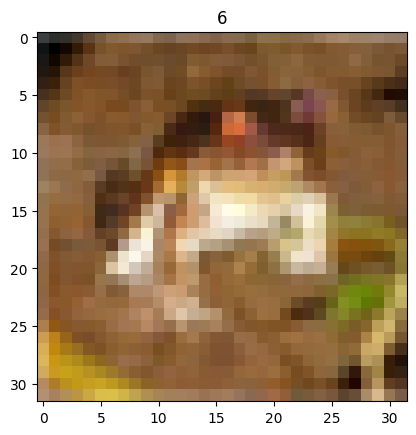

In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(image.permute(1,2,0).shape)
plt.imshow(image.permute(1,2,0)) # 图像shape[32, 32, 3] (height, width, colour channels)
plt.title(label)

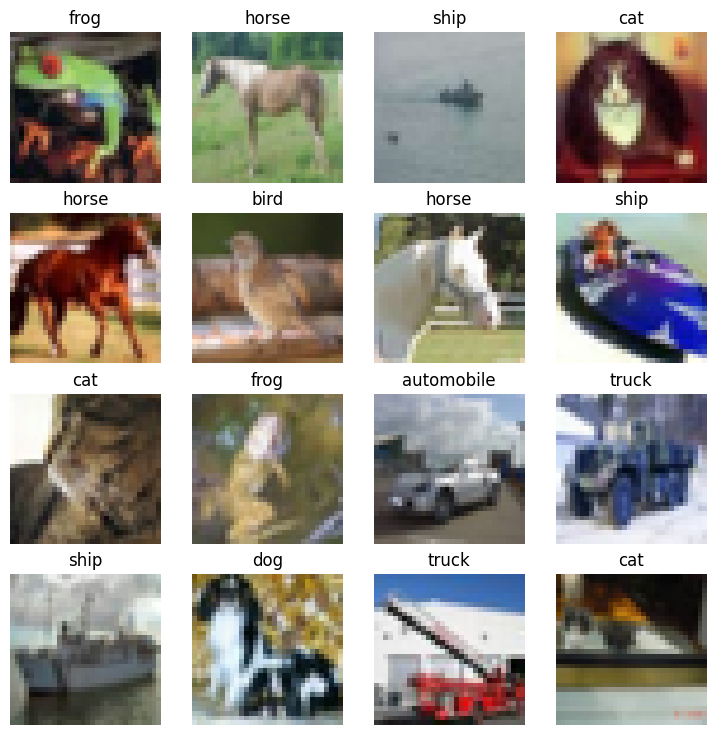

In [8]:
# 更多示例
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.permute(1,2,0))
    plt.title(class_names[label])
    plt.axis(False)

## 2. 准备 DataLoader

现在我们已经有一个数据集可以使用了。


* 下一步是用 `torch.utils.data.DataLoader`（简称 `DataLoader`）来准备它。

    * `DataLoader` 的作用正如其名，它帮助将数据加载到模型中，无论是用于训练还是推理。

    * 它将一个大型的 `Dataset` 转换为一个 Python 可迭代的小块数据。

    * 这些小块数据被称为**batches**（批次）或**mini-batch**（小批次），可以通过 `batch_size` 参数来设置。


* 为什么要这样做呢？因为这样计算效率更高。

    * 在一个理想的世界里，你可以一次性对所有数据进行前向传播和反向传播。

    * 但当你开始使用非常大的数据集时，除非你有无限的计算能力，否则将数据分成批次会更方便。

    * 使用**mini-batch**（小部分数据），每个 epoch 中的梯度下降会执行得更频繁（每个小批次执行一次，而不是每个 epoch 执行一次）。


* 一个好的批次大小是多少呢？

    * 但因为这是一个可以设置的值（一个**超参数**），你可以尝试各种不同的值，尽管通常使用 2 的幂次（例如 32、64、128、256、512）最为常见。


让我们为训练集和测试集创建 `DataLoader`。

In [9]:
from torch.utils.data import DataLoader

# 设置超参： batch size
BATCH_SIZE = 32

# 根据batch_size创建可迭代dataloader
train_dataloader = DataLoader(train_data, # 将train_data设置为dataloader式可迭代数据
    batch_size=BATCH_SIZE, 
    shuffle=True # 每个epoch是否打乱数据
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # 测试集通常不需要打乱数据
)

# 检查创建的dataloader
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x0000022244E373B0>, <torch.utils.data.dataloader.DataLoader object at 0x0000022244DE1E80>)
Length of train dataloader: 1563 batches of 32
Length of test dataloader: 313 batches of 32


In [10]:
# iterable数据可以使用next查看，下面查看dataloader内部的一个数据
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 3, 32, 32]), torch.Size([32]))

下面由于设置了`seed`，因此随机后查看到的依然和之前的是同一张图

Image size: torch.Size([3, 32, 32])
Label: 8, label size: torch.Size([])


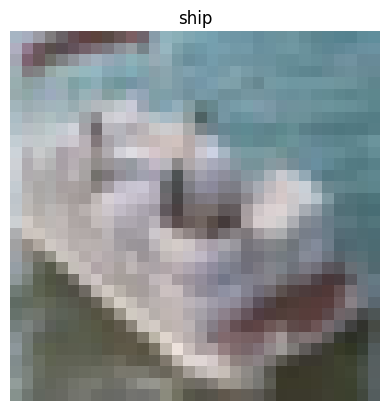

In [11]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.permute(1,2,0))
plt.title(class_names[label])
plt.axis("Off")
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

## 3. 模型 0：构建基准模型

数据已经加载并准备好了！

接下来，我们将通过继承 `nn.Module` 来构建一个**baseline model**（基准模型）。

**baseline model**是你能想象到的最简单的模型之一。

你可以将基准模型作为一个起点，并尝试用更复杂的后续模型来改进它。

我们的基准模型将由两个 [`nn.Linear()`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) 层组成。

我们在前面的部分已经做过类似的事情，但这里会有一个小的差别。

因为我们处理的是图像数据，我们将从一个不同的层开始，那就是 [`nn.Flatten()`](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html)。

`nn.Flatten()` 层将张量的多个维度压缩成一个向量。


In [12]:
# 创建flatten层
flatten_model = nn.Flatten() 

# 获取一个样本
x = train_features_batch[0]

# 对样本flatten
output = flatten_model(x) 

# 打印shape，看看前后差异
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape}    -> [color_channels, height*width]")


Shape before flattening: torch.Size([3, 32, 32]) -> [color_channels, height, width]
Shape after flattening: torch.Size([3, 1024])    -> [color_channels, height*width]


`nn.Flatten()` 层将张量的形状从 `[color_channels, height, width]` 转换为 `[color_channels, height*width]`。

为什么要这样做呢？

因为我们已经将像素数据从高度和宽度维度转换成了一个长长的**特征向量**。

而 `nn.Linear()` 层喜欢它们的输入是以特征向量的形式。

让我们使用 `nn.Flatten()` 作为第一层来创建我们的第一个模型。

In [13]:
from torch import nn
class CIFAR10ModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # neural networks like their inputs in vector form
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    
    def forward(self, x):
        return self.layer_stack(x)

我们已经有一个可以使用的基准模型类，现在让我们实例化一个模型。

我们需要设置以下参数：
* `input_shape=3072` - 这是进入模型的特征数量，在我们的例子中，它是目标图像的每个像素（3 通道 x 32 像素高 × 32 像素宽 = 3072 个特征）。
* `hidden_units=128` - 隐藏层中的单元数/神经元数，这个数字可以是任何你想要的值，我们先从 `128` 开始。
* `output_shape=len(class_names)` - 由于我们处理的是一个多类别分类问题，我们需要为数据集中的每个类别分配一个输出神经元。

让我们创建一个模型实例，并暂时将其发送到 CPU。

In [14]:
torch.manual_seed(42)

# 超参设置
model_0 = CIFAR10ModelV0(input_shape=3072, # 像素总数量
    hidden_units=128, # 隐含层数量
    output_shape=len(class_names) # 输出为数据库类别个数
)
model_0.to("cpu") # CPU上运行

CIFAR10ModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=128, bias=True)
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

### 3.1 设置损失函数, 优化器和评价指标

In [15]:
# 导入精度计算函数
import torchmetrics
device = "cuda" if torch.cuda.is_available() else "cpu"
accuracy_fn = torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# 设置loss和optimizer
loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

c:\Users\coachip\.conda\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3.2 创建一个用于测量实验时间的函数

损失函数和优化器已经准备好了，现在是时候开始训练模型了。

但在训练过程中，我们创建一个计时函数来测量模型在 CPU 上训练所需的时间。

我们的计时函数将从 Python 的 [`timeit` 模块](https://docs.python.org/3/library/timeit.html) 中导入 [`timeit.default_timer()` 函数](https://docs.python.org/3/library/timeit.html#timeit.default_timer)。

In [16]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """ 通过起始时刻计算运行时间

    Args:
        start (float): 起始计算时刻. 
        end (float): 结束计算时刻.
        device ([type], optional): 运行所在硬件.

    Returns:
        float: 运行时间，以秒为单位.
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### 3.3 创建训练循环并在数据批次上训练模型

看起来我们已经准备好了所有步骤：一个计时器、一个损失函数、一个优化器、一个模型，最重要的是，一些数据。

现在，让我们创建一个训练循环和一个测试循环来训练和评估我们的模型。

我们将使用与之前课程相同的步骤，但由于我们的数据现在是以批次形式提供的，我们将添加一个额外的循环来遍历我们的数据批次。

我们的数据批次包含在我们的`DataLoader`中，分别是用于训练数据分割的`train_dataloader`和用于测试数据分割的`test_dataloader`。

一个批次包含`BATCH_SIZE`个样本的`X`（特征）和`y`（标签）。由于我们使用的是`BATCH_SIZE=32`，因此我们的每个批次包含32个图像和目标的样本。

由于我们是在数据批次上进行计算，因此我们的损失和评估指标将**按批次**计算，而不是在整个数据集上计算。

这意味着我们需要将每个数据集的`DataLoader`中的批次数量分别除以我们的损失和准确率值。

让我们逐步进行：

1. 遍历轮次（epochs）。
2. 遍历训练批次，执行训练步骤，并按批次计算训练损失。
3. 遍历测试批次，执行测试步骤，并按批次计算测试损失。
4. 打印出正在发生的事情。
5. 计时（非必要）。


In [17]:
# 导入tqdm实现进度条功能
from tqdm.auto import tqdm
import torch.profiler

# 设置随机种子和起始运算时间
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# 设置epoch次数
epochs = 3

with torch.profiler.profile(
    schedule=torch.profiler.schedule(
        wait=2,
        warmup=2,
        active=6,
        repeat=1),
    on_trace_ready=torch.profiler.tensorboard_trace_handler('./log'),
    with_stack=True
) as profiler:
    # 创建training 和 testing循环
    for epoch in tqdm(range(epochs)):
        print(f"Epoch: {epoch}\n-------")
        ### 训练
        train_loss = 0
        # batch循环
        for batch, (X, y) in enumerate(train_dataloader):
            model_0.train() 
            # 1. 前向传播
            y_pred = model_0(X)

            # 2. 计算loss(per batch)
            loss = loss_fn(y_pred, y)
            
            train_loss += loss # 累积loss(per epoch) 

            # 3. 清空Optimizer历史梯度信息
            optimizer.zero_grad()

            # 4. Loss 反向传播
            loss.backward()

            # 5. 优化（更新权重）
            optimizer.step()

            profiler.step()

            # 打印当前进程
            if batch % 400 == 0:
                print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # 平均训练loss
    train_loss /= len(train_dataloader)
    
    ### 测试
    # 设置初始值，用于后面累积loss和acc 
    test_loss, test_acc = 0, 0 
    model_0.eval()
    accuracy_fn.reset()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. 前向传播
            test_pred = model_0(X)
           
            # 2. 累积loss
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. 累积acc
            test_acc += accuracy_fn(test_pred.argmax(dim=1), y)
            # accuracy_fn.update(test_pred.argmax(dim=1), y)
            
        
        # 平均测试loss
        test_loss /= len(test_dataloader)

        # 平均测试acc (per batch)
        test_acc /= len(test_dataloader)
        # test_acc = accuracy_fn.compute()

    profiler.stop()
    ## 打印
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc*100:.2f}%\n")

# 计算训练时间     
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/50000 samples
Looked at 12800/50000 samples
Looked at 25600/50000 samples
Looked at 38400/50000 samples


 33%|███▎      | 1/3 [00:11<00:22, 11.12s/it]

Epoch: 1
-------
Looked at 0/50000 samples
Looked at 12800/50000 samples
Looked at 25600/50000 samples
Looked at 38400/50000 samples


 67%|██████▋   | 2/3 [00:21<00:10, 10.57s/it]

Epoch: 2
-------
Looked at 0/50000 samples
Looked at 12800/50000 samples
Looked at 25600/50000 samples
Looked at 38400/50000 samples


100%|██████████| 3/3 [00:32<00:00, 10.85s/it]



Train loss: nan | Test loss: nan, Test acc: 10.00%

Train time on cpu: 34.609 seconds


## 4. 进行预测并获取模型 0 的结果

由于我们将要构建几个模型，因此编写一些代码以类似的方式评估它们是个好主意。

具体来说，让我们创建一个函数，该函数接收一个训练好的模型、一个`DataLoader`、一个损失函数和一个准确率函数。

该函数将使用模型对`DataLoader`中的数据进行预测，然后我们可以使用损失函数和准确率函数来评估这些预测。

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn):
    """返回包含名称, loss, acc的字典.

    Args:
        model (torch.nn.Module): PyTorch 模型
        data_loader (torch.utils.data.DataLoader): 评价数据集
        loss_fn (torch.nn.Module): loss函数.
        accuracy_fn: acc计算函数.

    Returns:
        (dict): 目标数据集上结果.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # 模型预测
            y_pred = model(X)
            
            # 每个batch累积loss和acc
            loss += loss_fn(y_pred, y)
            # acc += accuracy_fn(y_true=y, 
            #                     y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)
            acc += accuracy_fn(y_pred.argmax(dim=1), y)
        
        # 求平均
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__, 
            "model_loss": loss.item(),
            "model_acc": acc}

# 计算 model_0 在测试集上效果
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'model_name': 'CIFAR10ModelV0',
 'model_loss': 2.2618751525878906,
 'model_acc': tensor(0.2431)}

后续我们也从这三个维度对比模型。

基准模型的训练时间没花多久，但是效果不怎么样，我们是否可以通过简单添加层数提升效果呢？

In [ ]:
class CIFAR10ModelV00(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # neural networks like their inputs in vector form
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=hidden_units//8),
            nn.Linear(in_features=hidden_units//8, out_features=hidden_units//16),
            nn.Linear(in_features=hidden_units//16, out_features=output_shape)
        )
    
    def forward(self, x):
        return self.layer_stack(x)

torch.manual_seed(42)

# 超参设置
model_00 = CIFAR10ModelV0(input_shape=3072, # 像素总数量
    hidden_units=1024, # 隐含层数量
    output_shape=len(class_names) # 输出为数据库类别个数
)
model_00.to("cpu") # CPU上运行

from tqdm.auto import tqdm
import torch.profiler

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

with torch.profiler.profile(
    schedule=torch.profiler.schedule(
        wait=2,
        warmup=2,
        active=6,
        repeat=1),
    on_trace_ready=torch.profiler.tensorboard_trace_handler('./log'),
    with_stack=True
) as profiler:
    for epoch in tqdm(range(epochs)):
        print(f"Epoch: {epoch}\n-------")
        train_loss = 0
        for batch, (X, y) in enumerate(train_dataloader):
            model_0.train() 
            y_pred = model_0(X)

            loss = loss_fn(y_pred, y)

            train_loss += loss

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            profiler.step()

            if batch % 400 == 0:
                print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)
    
    ### Testing
    test_loss, test_acc = 0, 0 
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_0(X)
           
            test_loss += loss_fn(test_pred, y) 

            # test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
            test_acc += accuracy_fn(test_pred.argmax(dim=1), y)
        
        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)

    profiler.stop()
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")
   
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/50000 samples
Looked at 12800/50000 samples
Looked at 25600/50000 samples
Looked at 38400/50000 samples


 33%|███▎      | 1/3 [00:11<00:23, 11.92s/it]

Epoch: 1
-------
Looked at 0/50000 samples
Looked at 12800/50000 samples
Looked at 25600/50000 samples
Looked at 38400/50000 samples


 67%|██████▋   | 2/3 [00:23<00:11, 11.60s/it]

Epoch: 2
-------
Looked at 0/50000 samples
Looked at 12800/50000 samples
Looked at 25600/50000 samples
Looked at 38400/50000 samples


100%|██████████| 3/3 [00:34<00:00, 11.52s/it]



Train loss: 2.04745 | Test loss: 2.41099, Test acc: 0.23%

Train time on cpu: 36.520 seconds


model_00中Fc的层数从原来的两层增加到了四层，但是效果和model_0基本一样，并没有因为层数增加而提高性能，这是为什么呢？

这是因为Fc本身只包含乘/加运算的线性函数，多层Fc和单层Fc从理论上说是等价的，因此单纯增加Fc层的个数并不能提升分类准确率。

## 6. 模型 1：通过非线性构建更好的模型

怎么理解非线性？

从几何角度看，线性函数能够在二维空间中画出一条直线，而非线性函数则能画出曲线。

例如有一组形如银河系状的数据，如果要将不同悬臂分类，则需要能够表示曲线的分类器。

记住，线性意味着“直线”，而非线性意味着“非直线”。

让我们来验证一下。

我们将通过重新构建一个类似之前的模型来进行尝试，但这次我们会在每个线性层之间加入非线性函数（`nn.ReLU()`）。

In [ ]:
# 添加识别平台代码，自动切换硬件运算单元
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# 创建带有线性/非线性层的网络
class CIFAR10ModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flatten inputs into single vector
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units//8),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units//8, out_features=hidden_units//16),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units//16, out_features=output_shape),
            nn.ReLU()
        )
    
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

现在我们用之前相同的设置来实例化它。

我们需要 `input_shape=3072`（等于我们图像数据的特征数量）、`hidden_units=1024`，以及 `output_shape=len(class_names)`（每个类别一个输出单元）。

> **注意：** 注意我们是如何保持模型的大部分设置不变的，只改变了一个地方：添加了非线性层。这是进行一系列机器学习实验的标准做法，改变一件事，看看会发生什么，然后再重复。

In [ ]:
torch.manual_seed(42)
model_1 = CIFAR10ModelV1(input_shape=3072, 
    hidden_units=1024,
    output_shape=len(class_names) 
).to(device) # 将模型载入硬件，CPU或GPU
next(model_1.parameters()).device # 查看模型所在硬件

device(type='cpu')

同样操作：添加loss函数和optimizer

In [ ]:
# from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), 
                            lr=0.05)

### 6.2 将训练和测试循环封装成函数

到目前为止，我们一直在反复编写训练和测试循环。

这次我们将会将它们放入函数中，以便可以反复调用。

由于我们现在使用的是设备不可知代码，我们会确保对特征（`X`）和目标（`y`）张量调用`.to(device)`。

对于训练循环，我们将创建一个名为`train_step()`的函数，该函数接受一个模型、一个`DataLoader`、一个损失函数和一个优化器。

测试循环将类似，但会命名为`test_step()`，它将接受一个模型、一个`DataLoader`、一个损失函数和一个评估函数。

> **注意：** 由于这些是函数，你可以按照自己喜欢的任何方式进行定制。我们在这里制作的可以被视为我们特定分类用例的基础训练和测试函数。

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # 数据载入CPU/GPU
        X, y = X.to(device), y.to(device)

        # 1. 前向推理
        y_pred = model(X)

        # 2. 计算loss
        loss = loss_fn(y_pred, y)
        train_loss += loss

        train_acc += accuracy_fn(y_pred.argmax(dim=1), y)

        # 3. 清空Optimizer历史梯度
        optimizer.zero_grad()

        # 4. 反向传播
        loss.backward()

        # 5. 优化参数
        optimizer.step()

    # 每个epoch计算loss和acc并显示
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc*100:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # 设置为eval模式
    # 开启inference上下文模式
    with torch.inference_mode(): 
        for X, y in data_loader:
            # 载入数据到CPU/GPU
            X, y = X.to(device), y.to(device)
            
            # 1. 前向推理
            test_pred = model(X)
            
            # 2. 计算loss和acc
            test_loss += loss_fn(test_pred, y)

            test_acc += accuracy_fn(test_pred.argmax(dim=1), y)
        
        # 计算并显示test loss/acc
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

现在我们有了用于训练和测试模型的函数，

我们将在另一个循环中运行它们，每个周期（epoch）运行一次。

这样一来，每个周期都会经历一次训练步骤和一次测试步骤。

我们还可以对代码进行计时，看看在 CPU/GPU 上运行需要多长时间。

> **注意：** 你可以自定义测试步骤的频率。有些人每五轮或十轮进行一次测试，或者像我们这样，每轮都进行一次测试。

In [ ]:
torch.manual_seed(42)

# 运行时间
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=model_1, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.89157 | Train accuracy: 35.47%


 33%|███▎      | 1/3 [00:23<00:47, 23.92s/it]

Test loss: 1.72590 | Test accuracy: 0.42%

Epoch: 1
---------
Train loss: 1.49950 | Train accuracy: 47.33%


 67%|██████▋   | 2/3 [00:48<00:24, 24.08s/it]

Test loss: 1.46553 | Test accuracy: 0.48%

Epoch: 2
---------
Train loss: 1.36082 | Train accuracy: 52.25%


100%|██████████| 3/3 [01:12<00:00, 24.25s/it]

Test loss: 1.44626 | Test accuracy: 0.49%

Train time on cpu: 72.742 seconds


In [ ]:
# 将数据载入硬件
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn, 
               device: torch.device = device):
    """评价模型在数据上效果.

    Args:
        model (torch.nn.Module): 模型.
        data_loader (torch.utils.data.DataLoader): 测评数据库.
        loss_fn (torch.nn.Module): 损失函数.
        accuracy_fn: 准确率计算函数，比对预测结果和GT之间的差异.
        device (str, optional): 运算硬件

    Returns:
        (dict): 在data_loader上的评价结果.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # 将数据载入可用硬件(和之前eval_model的差异所在)
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_pred.argmax(dim=1), y)
        
        # 计算loss/acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 1
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

{'model_name': 'CIFAR10ModelV1',
 'model_loss': 1.44625985622406,
 'model_acc': tensor(0.4884)}

In [ ]:
# 查看 baseline 模型结果
model_0_results

{'model_name': 'CIFAR10ModelV0',
 'model_loss': 2.2618751525878906,
 'model_acc': tensor(0.2431)}

可以看到，添加非线性函数后的模型准确率有了明显提升。

但是注意：这并不代表含有非线性函数的模型一定强与线性模型，需要看数据的分布。

## 7. 模型 2：构建卷积神经网络（CNN）

上面的模型，主要将输入数据拉平，然后使用FC左运算，这些模型中并未使用图像空间信息，接下来引入**卷积神经网络（CNN）**.

CNN 以其在视觉数据中寻找模式的能力而闻名。

既然我们正在处理的是视觉数据，让我们看看使用 CNN 模型是否能比基线模型表现得更好。

它遵循典型的卷积神经网络结构：

`输入层 -> [卷积层 -> 激活层 -> 池化层] -> 输出层`

其中，`[卷积层 -> 激活层 -> 池化层]` 的内容可以根据需要进行扩展和多次重复。

In [ ]:
# 创建卷积神经网络
class CIFAR10ModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1, 
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units*8,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) 
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units*8, hidden_units*8, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units*8, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*8*8, 
                      out_features=hidden_units*8),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units*8, 
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)
model_2 = CIFAR10ModelV2(input_shape=3, 
    hidden_units=4, 
    output_shape=len(class_names)).to(device)
model_2

CIFAR10ModelV2(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (block_1): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)

### 7.1 逐步了解 `nn.Conv2d()`

我们可以直接使用上面的模型来看看会发生什么，但让我们先了解一下我们新增的两个层：
* [`nn.Conv2d()`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)，也称为卷积层。
* [`nn.MaxPool2d()`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)，也称为最大池化层。

> **问题：** `nn.Conv2d()` 中的“2d”是什么意思？
>
> 2d 代表二维数据。也就是说，我们的图像有两个维度：高度和宽度。虽然还有颜色通道这一维度，但每个颜色通道本身也有两个维度：高度和宽度。
>
> 对于其他维度的数据（例如，文本的 1D 或 3D 物体的 3D），还有 `nn.Conv1d()` 和 `nn.Conv3d()`。

为了测试这些层，我们先创建一些dummy数据。

In [ ]:
torch.manual_seed(42)

# 随机生成数据
images = torch.randn(size=(32, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # 查看单个样本
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]") 
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,

好的，让我们来创建一个带有各种参数的 `nn.Conv2d()` 示例：

- `in_channels`（整数）：输入图像的通道数。
- `out_channels`（整数）：卷积操作产生的通道数。
- `kernel_size`（整数或元组）：卷积核/滤波器的大小。
- `stride`（整数或元组，可选）：卷积核每次移动的步长。默认值为 1。
- `padding`（整数、元组或字符串）：在输入的四周添加的填充。默认值为 0。

In [ ]:
torch.manual_seed(42)

# 创建一个卷积层
# (可以尝试改变下面卷积层中的超参数，看看输出结果有什么不同)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # 这里还可以设置为 "valid" 或 "same" 

# 将数据送入conv层
conv_layer(test_image) # Note: If running PyTorch <1.11.0, this will error because of shape issues (nn.Conv.2d() expects a 4d tensor as input) 

tensor([[[ 1.5396,  0.0516,  0.6454,  ..., -0.3673,  0.8711,  0.4256],
         [ 0.3662,  1.0114, -0.5997,  ...,  0.8983,  0.2809, -0.2741],
         [ 1.2664, -1.4054,  0.3727,  ..., -0.3409,  1.2191, -0.0463],
         ...,
         [-0.1541,  0.5132, -0.3624,  ..., -0.2360, -0.4609, -0.0035],
         [ 0.2981, -0.2432,  1.5012,  ..., -0.6289, -0.7283, -0.5767],
         [-0.0386, -0.0781, -0.0388,  ...,  0.2842,  0.4228, -0.1802]],

        [[-0.2840, -0.0319, -0.4455,  ..., -0.7956,  1.5599, -1.2449],
         [ 0.2753, -0.1262, -0.6541,  ..., -0.2211,  0.1999, -0.8856],
         [-0.5404, -1.5489,  0.0249,  ..., -0.5932, -1.0913, -0.3849],
         ...,
         [ 0.3870, -0.4064, -0.8236,  ...,  0.1734, -0.4330, -0.4951],
         [-0.1984, -0.6386,  1.0263,  ..., -0.9401, -0.0585, -0.7833],
         [-0.6306, -0.2052, -0.3694,  ..., -1.3248,  0.2456, -0.7134]],

        [[ 0.4414,  0.5100,  0.4846,  ..., -0.8484,  0.2638,  1.1258],
         [ 0.8117,  0.3191, -0.0157,  ...,  1

In [ ]:
# torch1.11版本之前需要conv2d的输入为四维数据，其中第0维为batch维
test_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [ ]:
# 四维数据经过conv层后，在batch维度会保持输入时尺寸
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

In [ ]:
torch.manual_seed(42)
# 改变参数
conv_layer_2 = nn.Conv2d(in_channels=3,
                         out_channels=10,
                         kernel_size=(5, 5), # kernel通常是矩形的，但并不绝对
                         stride=2,
                         padding=0)

# 传入单个sample
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

不同的超参组合可能会得到不同的输出结果。

`nn.Conv2d()` 正在提取/压缩图像中存储的信息。

它是根据输入数据和超参数控制计算过程。

这与我们之前构建的所有其他神经网络的目标是一样的。

数据输入后，各层会尝试更新其内部参数（模式），以降低损失函数的值，而优化器在这个过程中提供了帮助。

唯一的区别在于不同层计算参数更新的方式，或者用 PyTorch 的术语来说，就是层的 `forward()` 方法中所执行的操作。

如果我们查看 `conv_layer_2.state_dict()`，我们会发现与之前类似的权重和偏置设置。

In [ ]:
# 查看conv_layer_2内部的可训练参数（weight, bias）
print(conv_layer_2.state_dict())

OrderedDict({'weight': tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
          [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
          [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
          [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
          [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],

         [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
          [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
          [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
          [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
          [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],

         [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
          [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
          [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
          [-0.0241,  0.0958, -0.0684, -0.0689, -0.0689],
          [ 0.1039,  0.0385,  0.1111, -0.0953, -0.1145]]],


        [[[-0.0903, -0.0777,  0.0468,  0.0413,  0.0959],
          [-0.0596, -0.0787,  0.0613, -0.0467,  0.0701],


一大堆随机数构成了权重和偏置张量。

这些张量的形状是由我们在设置 `nn.Conv2d()` 时传入的参数决定的。

让我们来检查一下它们的具体形状。

In [ ]:
# 获取conv_layer_2中weight 和 bias的shape 
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} -> [out_channels=10]")

conv_layer_2 weight shape: 
torch.Size([10, 3, 5, 5]) -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]

conv_layer_2 bias shape: 
torch.Size([10]) -> [out_channels=10]


> **问题：** 我们应该如何设置 `nn.Conv2d()` 层的参数？
>
> 这是个好问题。但与机器学习中的许多其他事情一样，这些参数的值并不是固定的（并且由于这些值是我们自己可以设置的，因此它们被称为“**超参数**”）。
>
> 最好的方法是尝试不同的值，看看它们如何影响模型的性能。
>
> 或者更好的方法是，找到一个与你的问题类似的示例，并直接复制它。

他们的核心思想仍然是：从随机数开始，然后更新它们以更好地表示数据。

### 7.2 逐步了解 `nn.MaxPool2d()`

现在我们来看看数据通过 `nn.MaxPool2d()` 时会发生什么。

下面用类似的方式看看`MaxPool2d`的参数还有输入输出。

对于陌生的算子，通过查看输入输出，超参数等方式，是理解它运行原理的好方法。

对于网络如果有不清楚的地方，也可以从小处着手。

选择网络的一个单独层，将一些数据传递通过它，看看会发生什么。

In [ ]:
# 打印原始图像尺寸和unsqueezed尺寸
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# 创建maxpool2d层
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# 数据送入刚才创建的conv层
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# 数据送入刚才创建的pool层
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 31, 31])


注意在 `nn.MaxPool2d()` 层的输入和输出中形状的变化。

`nn.MaxPool2d()` 层的 `kernel_size` 会影响输出形状的大小。

在我们的例子中，形状从 `62x62` 的图像减半为 `31x31` 的图像。

让我们用一个更小的张量来看看这个过程是如何工作的。

In [ ]:
torch.manual_seed(42)
# 创建随机数据
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"Random tensor:\n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# 创建pool层
max_pool_layer = nn.MaxPool2d(kernel_size=2) # see what happens when you change the kernel_size value 

# 将随机数传入pool层
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor:\n{max_pool_tensor} <- this is the maximum value from random_tensor")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")

Random tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])

Max pool tensor:
tensor([[[[0.3367]]]]) <- this is the maximum value from random_tensor
Max pool tensor shape: torch.Size([1, 1, 1, 1])


注意 `random_tensor` 和 `max_pool_tensor` 的最后两个维度，它们从 `[2, 2]` 变为 `[1, 1]`。本质上，它们被减半了。而且，这种变化会因 `nn.MaxPool2d()` 的 `kernel_size` 不同而有所不同。同时，注意到 `max_pool_tensor` 中保留的值是 `random_tensor` 中的**最大值**。

这是神经网络拼图中的另一个重要部分。本质上，**神经网络的每一层都在试图将数据从高维空间压缩到低维空间**。换句话说，就是从大量的数字（原始数据）中学习模式，这些模式是预测性的，同时又比原始值的大小更小。

从人工智能的角度来看，你可以认为神经网络的整个目标是*压缩*信息。

这意味着，从神经网络的角度来看，智能就是压缩。`nn.MaxPool2d()` 层的使用理念也是如此：从张量的一部分中取最大值，而忽略其余部分。本质上，这是在降低张量的维度，同时仍然保留（希望是）相当一部分的信息。

`nn.Conv2d()` 层也是如此，只是它不是简单地取最大值，而是对数据执行卷积操作（可以在 [CNN Explainer 网页](https://poloclub.github.io/cnn-explainer/) 上看到实际操作）。

> **练习：** 你觉得 [`nn.AvgPool2d()`](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html) 层的作用是什么？尝试像上面那样创建一个随机张量并将其传递通过该层。检查输入和输出的形状以及输入和输出的值。

> **课外拓展：** 查找“最常见的卷积神经网络”，你发现了哪些架构？其中有没有包含在 [`torchvision.models`](https://pytorch.org/vision/stable/models.html) 库中的？你觉得可以用它们做什么？

### 7.3 为 `model_2` 设置损失函数和优化器

现在是时候继续前进并开始训练了！

让我们设置一个损失函数和一个优化器。

我们将使用之前用过的函数，`nn.CrossEntropyLoss()` 作为损失函数（因为我们处理的是多类别分类数据）。

并且使用 `torch.optim.SGD()` 作为优化器，优化 `model_2.parameters()`，学习率设置为 `0.008`。

In [ ]:
# 设置loss和优化器
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), 
                             lr=0.008)

### 7.4 使用训练和测试函数训练和测试 `model_2`

损失函数和优化器已经准备好了！

现在是时候开始训练和测试了。

我们将使用之前创建的 `train_step()` 和 `test_step()` 函数。同时，我们还会测量训练和测试的时间，以便与之前的模型进行比较。

In [ ]:
torch.manual_seed(42)

# 测试时间
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# 训练并测试模型
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=model_2, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 2.29526 | Train accuracy: 12.35%


 33%|███▎      | 1/3 [00:40<01:21, 40.81s/it]

Test loss: 2.20337 | Test accuracy: 0.21%

Epoch: 1
---------
Train loss: 1.93640 | Train accuracy: 30.05%


 67%|██████▋   | 2/3 [01:24<00:42, 42.27s/it]

Test loss: 1.76405 | Test accuracy: 0.37%

Epoch: 2
---------
Train loss: 1.67360 | Train accuracy: 39.58%


100%|██████████| 3/3 [02:06<00:00, 42.25s/it]

Test loss: 1.60338 | Test accuracy: 0.42%

Train time on cpu: 126.753 seconds


看起来卷积层和最大池化层的性能和全连接层相当。

让我们用我们的 `eval_model()` 函数来评估一下 `model_2` 的结果吧。

In [ ]:
# eval模型2
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results

{'model_name': 'CIFAR10ModelV2',
 'model_loss': 1.60338294506073,
 'model_acc': tensor(0.4179)}

## 8. 比较模型结果和训练时间

我们已经训练了三种不同的模型。

1. `model_0` —— 我们的基线模型，包含两个 `nn.Linear()` 层。
2. `model_1` —— 与基线模型相同的设置，但在 `nn.Linear()` 层之间加入了 `nn.ReLU()` 层。
3. `model_2` —— 我们的第一个卷积神经网络模型。

这是机器学习中的常规做法。

构建多个模型并进行多次训练实验，以找出表现最好的模型。

让我们将模型结果字典合并到一个数据框中，看看哪个模型表现最好。

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,CIFAR10ModelV0,2.261875,tensor(0.2431)
1,CIFAR10ModelV1,1.446260,tensor(0.4884)
2,CIFAR10ModelV2,1.603383,tensor(0.4179)


In [ ]:
# Add training times to results comparison
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,CIFAR10ModelV0,2.261875,tensor(0.2431),36.519870
1,CIFAR10ModelV1,1.446260,tensor(0.4884),72.741523
2,CIFAR10ModelV2,1.603383,tensor(0.4179),126.752871


看起来全连接网络模型（`CIFARModelV1`）表现最好（损失最低，准确率最高）。


### 性能与速度的权衡

在机器学习中，需要注意的一个问题是**性能与速度的权衡**。

一般来说，更大、更复杂的模型能够获得更好的性能。

然而，这种性能提升往往是以牺牲训练速度和推理速度为代价的。

> **注意：** 你得到的训练时间将非常依赖于你使用的硬件。
>
> 一般来说，你拥有的 CPU 核心越多，模型在 CPU 上的训练速度就越快。对于 GPU 也是如此。
>
> 更新的硬件通常也会因为技术的进步而更快地训练模型。

上面性能信息显示，model_2的训练时间最长，我们看看他们的参数量分别是多少。

同时看看他们的参数量，到底付出了多少代价得到了各自的准确率。

这里引入torchinfo工具，能够方便查看模型各层和总体的参数信息，在评估的时候需要设定输入数据的shape信息。

In [ ]:
import torchinfo
from torchinfo import summary
summary(model_0, (1,3,32,32)) 

Layer (type:depth-idx)                   Output Shape              Param #
CIFAR10ModelV0                           [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Flatten: 2-1                      [1, 3072]                 --
│    └─Linear: 2-2                       [1, 128]                  393,344
│    └─Linear: 2-3                       [1, 10]                   1,290
Total params: 394,634
Trainable params: 394,634
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.39
Input size (MB): 0.01
Forward/backward pass size (MB): 0.00
Params size (MB): 1.58
Estimated Total Size (MB): 1.59

In [ ]:
import torchinfo
from torchinfo import summary
summary(model_1, (1,3,32,32)) 

Layer (type:depth-idx)                   Output Shape              Param #
CIFAR10ModelV1                           [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Flatten: 2-1                      [1, 3072]                 --
│    └─Linear: 2-2                       [1, 1024]                 3,146,752
│    └─ReLU: 2-3                         [1, 1024]                 --
│    └─Linear: 2-4                       [1, 128]                  131,200
│    └─ReLU: 2-5                         [1, 128]                  --
│    └─Linear: 2-6                       [1, 64]                   8,256
│    └─ReLU: 2-7                         [1, 64]                   --
│    └─Linear: 2-8                       [1, 10]                   650
│    └─ReLU: 2-9                         [1, 10]                   --
Total params: 3,286,858
Trainable params: 3,286,858
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.29
Input size (MB): 0.01
F

In [ ]:
import torchinfo
from torchinfo import summary
summary(model_2, (1,3,32,32)) 

Layer (type:depth-idx)                   Output Shape              Param #
CIFAR10ModelV2                           [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-1                       [1, 4, 32, 32]            112
│    └─ReLU: 2-2                         [1, 4, 32, 32]            --
│    └─Conv2d: 2-3                       [1, 32, 32, 32]           1,184
│    └─ReLU: 2-4                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-5                    [1, 32, 16, 16]           --
├─Sequential: 1-2                        [1, 4, 8, 8]              --
│    └─Conv2d: 2-6                       [1, 32, 16, 16]           9,248
│    └─ReLU: 2-7                         [1, 32, 16, 16]           --
│    └─Conv2d: 2-8                       [1, 4, 16, 16]            1,156
│    └─ReLU: 2-9                         [1, 4, 16, 16]            --
│    └─MaxPool2d: 2-10                   [1, 4, 8, 8]              --
├─Seq

从上面统计结果看，model_0/1/2三个模型的参数数量分别为：394,634; 3,286,858; 20,254

model_2明显小于model_0/1，甚至只有model_1的0.6%，而超过了和model_1的准确率。

可视化下准确率：

Text(0, 0.5, 'model')

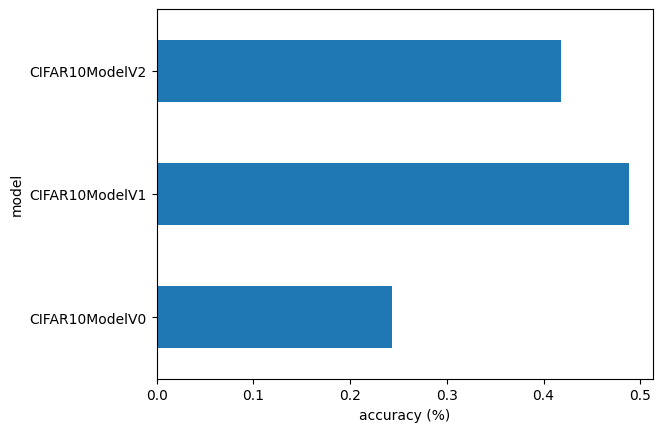

In [ ]:
# 可视化模型结果
# 将torch.tensor转为一般
compare_results['model_acc'] = compare_results['model_acc'].apply(
    lambda t: t.cpu().item() if isinstance(t, torch.Tensor) else t
)
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

## 9. 使用最佳模型进行随机预测并评估

好的，我们已经比较了各个模型，现在让我们进一步评估综合表现最好的模型——`model_2`。

为此，我们创建一个 `make_predictions()` 函数，通过它可以将模型和一些数据传递进去，让模型进行预测。

In [ ]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # 准备样本
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # 前向推理
            pred_logit = model(sample)

            # 获取概率
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # 收集所有预测结果
            pred_probs.append(pred_prob.cpu())
            
    # 整理结果
    return torch.stack(pred_probs)

In [ ]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# 查看第一个样本
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([3, 32, 32])
Test sample label: 9 (truck)


In [ ]:
# 用模型2测试
pred_probs= make_predictions(model=model_2, 
                             data=test_samples)

# 查看前两个预测结果
pred_probs[:2]

tensor([[0.0423, 0.0627, 0.0066, 0.0172, 0.0150, 0.0048, 0.0275, 0.0151, 0.0264,
         0.7823],
        [0.0137, 0.0113, 0.1780, 0.1764, 0.1012, 0.2563, 0.0585, 0.1544, 0.0202,
         0.0298]])

In [ ]:
# 将概率转为argmax
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([9, 5, 8, 4, 6, 6, 7, 0, 0])

In [ ]:
# 预测的结果和GT相比有些差异 
test_labels, pred_classes

([9, 2, 1, 3, 7, 3, 7, 0, 9], tensor([9, 5, 8, 4, 6, 6, 7, 0, 0]))

现在我们的预测类别与测试标签的格式一致了，我们可以进行比较了。

因为我们处理的是图像数据，我们可视化结果。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9158674..1.7560488].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4972931..1.7710396].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.8759745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9641825..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4488223..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.931972

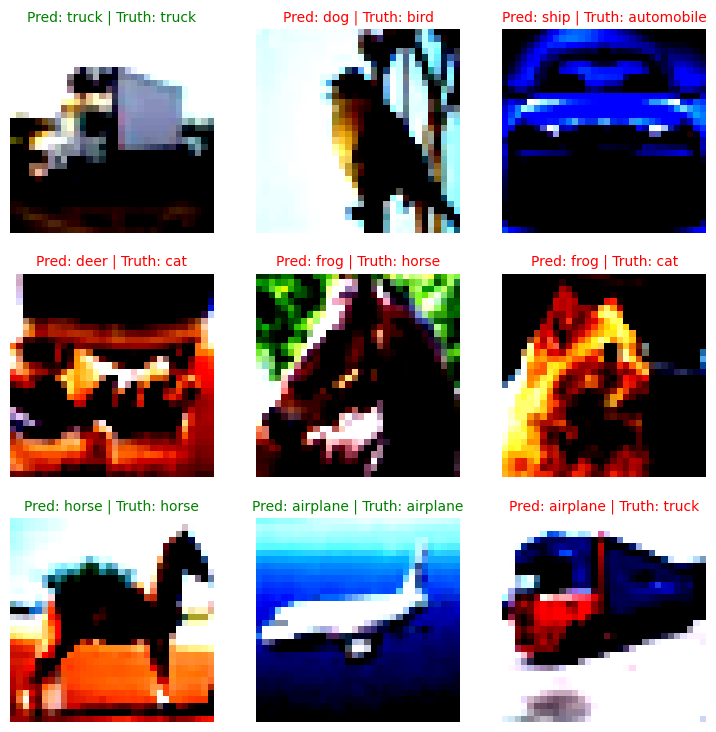

In [ ]:
# 画出预测结果
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # 创建子图
  plt.subplot(nrows, ncols, i+1)

  # 目标图
  plt.imshow(sample.squeeze().permute(1,2,0))

  # 查找对应label
  pred_label = class_names[pred_classes[i]]

  # 获取GT label
  truth_label = class_names[test_labels[i]] 

  # 创建title
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  # 查看是否与GT一致
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # 一致则标绿
  else:
      plt.title(title_text, fontsize=10, c="r") # 错误则标红
  plt.axis(False)

## 10. 制作混淆矩阵以进一步评估预测结果

对于分类问题，我们可以使用许多[不同的评估指标](https://www.learnpytorch.io/02_pytorch_classification/#9-more-classification-evaluation-metrics)。

其中最直观的一种是[混淆矩阵](https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/)。

混淆矩阵可以显示你的分类模型在预测和真实标签之间的混淆情况。

为了制作一个混淆矩阵，我们将经历以下三个步骤：
1. 使用我们训练好的模型 `model_2` 进行预测（混淆矩阵会比较预测结果和真实标签）。
2. 使用 [`torchmetrics.ConfusionMatrix`](https://torchmetrics.readthedocs.io/en/latest/references/modules.html?highlight=confusion#confusionmatrix) 制作混淆矩阵。
3. 使用 [`mlxtend.plotting.plot_confusion_matrix()`](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_confusion_matrix/) 绘制混淆矩阵。

让我们先从使用我们训练好的模型进行预测开始。

In [ ]:
from tqdm.auto import tqdm

# 1. 使用训练好的模型预测
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # 将数据送入目标device
    X, y = X.to(device), y.to(device)
    # 前向推理
    y_logit = model_2(X)
    # 将预测结果转为概率并取最佳值
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # 送入CPU进行预测
    y_preds.append(y_pred.cpu())
# 将预测结果拼接起来
y_pred_tensor = torch.cat(y_preds)

Making predictions: 100%|██████████| 313/313 [00:03<00:00, 80.95it/s]


现在我们已经有了预测结果，让我们继续执行步骤 2 和 3：
2. 使用 [`torchmetrics.ConfusionMatrix`](https://torchmetrics.readthedocs.io/en/latest/references/modules.html?highlight=confusion#confusionmatrix) 制作混淆矩阵。
3. 使用 [`mlxtend.plotting.plot_confusion_matrix()`](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_confusion_matrix/) 绘制混淆矩阵。

首先，我们需要确保已经安装了 `torchmetrics` 和 `mlxtend`（这两个库将帮助我们制作和可视化混淆矩阵）。

In [ ]:
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.23.4


In [ ]:
import mlxtend 
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.23.4


安装 `torchmetrics` 和 `mlxtend`后，我们就可以开始制作混淆矩阵了！

首先，我们需要创建一个 `torchmetrics.ConfusionMatrix` 实例，并通过设置 `num_classes=len(class_names)` 来告诉它我们正在处理多少个类别。

然后，我们将通过传递模型的预测结果（`preds=y_pred_tensor`）和目标值（`target=test_data.targets`）来创建一个混淆矩阵（以张量格式）。

最后，我们可以使用 `mlxtend.plotting` 中的 `plot_confusion_matrix()` 函数来绘制混淆矩阵。

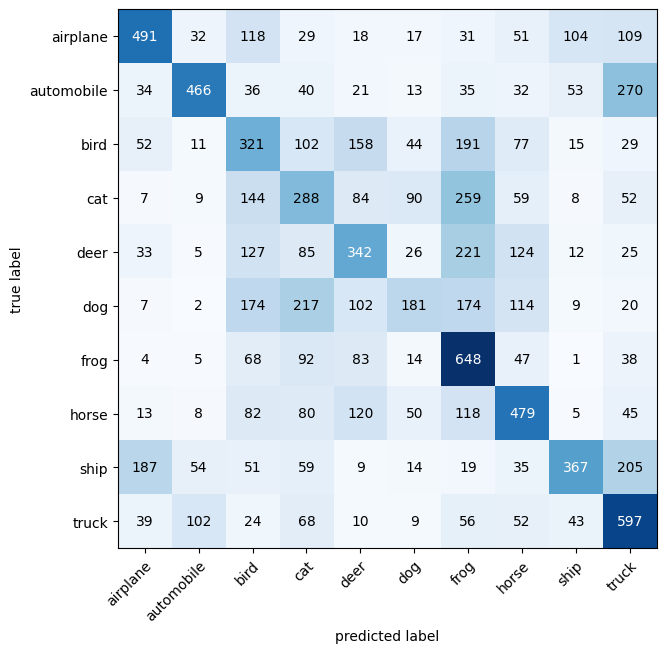

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. 设置并创建混淆矩阵
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=torch.tensor(test_data.targets))

# 3. 画出混淆矩阵
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib通常与NumPy一起用
    class_names=class_names, # 将行列转为label name
    figsize=(10, 7)
)

从混淆矩阵中可以看出，我们的模型在cat/deer/dog上表现不佳（理想情况下，模型只会在对角线方块中有值，其他地方都是 0）。

模型在一些相似的类别之间最容易混淆，例如，将标签为“dog”的图片预测为“cat”。

同样，模型也会将标签为“deer”的类别预测为“bird”。

这种信息通常比单一的准确率指标更有用，因为它告诉我们模型在哪些地方出错了。

它还能提示模型出错的原因。

有时模型将标签为“dog”的图片预测为“cat”是可以理解的。

我们可以利用这些信息进一步检查模型和数据，看看如何改进。

> **练习：** 使用训练好的 `model_2` 对测试 CIFAR10 数据集进行预测。然后绘制一些模型预测错误的图片，以及它们应该具有的标签。在可视化这些预测后，你认为这更多是模型错误还是数据错误？也就是说，模型可以做得更好，还是数据的标签之间太接近（例如，“dog”标签与“cat”太相似）？

## 11. 保存和加载表现最佳的模型

让我们通过保存和加载表现最佳的模型来结束这一部分。

回顾我们在上节课学到的内容，我们可以使用以下方法保存和加载 PyTorch 模型：
* `torch.save` — 一个函数，用于保存整个 PyTorch 模型或模型的 `state_dict()`。
* `torch.load` — 一个函数，用于加载保存的 PyTorch 对象。
* `torch.nn.Module.load_state_dict()` — 一个函数，用于将保存的 `state_dict()` 加载到现有的模型实例中。

你可以在 [PyTorch 保存和加载模型文档](https://pytorch.org/tutorials/beginner/saving_loading_models.html)中看到更多关于这些函数的内容。

现在，让我们保存 `model_2` 的 `state_dict()`，然后将其重新加载并进行评估，以确保保存和加载操作正确无误。

In [ ]:
from pathlib import Path

# 创建陌路
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, # 创建父目录
                 exist_ok=True # 存在时不报错
)

# 设置模型名称
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 保存模型
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), # 只保存state_dict()，其中只包含学习到的参数
           f=MODEL_SAVE_PATH)

Saving model to: models\03_pytorch_computer_vision_model_2.pth


既然我们已经保存了模型的 `state_dict()`，现在可以使用 `load_state_dict()` 和 `torch.load()` 的组合将其重新加载。

由于我们使用的是 `load_state_dict()`，我们需要创建一个与保存的 `state_dict()` 具有相同输入参数的新 `CIFAR10ModelV2()` 实例。

In [ ]:
# 创建一个新的CIFAR10ModelV2实例
# 如果没有保存，这里会报错
loaded_model_2 = CIFAR10ModelV2(input_shape=3, 
                                hidden_units=4, 
                                output_shape=10) 

# 载入保存的state_dict()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# 将模型送入目标硬件
loaded_model_2 = loaded_model_2.to(device)

现在我们已经加载了模型，可以使用 `eval_model()` 函数对其进行评估，以确保其参数与保存前的 `model_2` 表现相似。

In [ ]:
# 评价载入的模型
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

{'model_name': 'CIFAR10ModelV2',
 'model_loss': 1.60338294506073,
 'model_acc': tensor(0.4179)}

可以使用 `torch.isclose()` 来比较两个张量是否在指定的容差范围内接近。这个函数非常适合用来检查模型的预测结果是否与预期结果足够接近，尤其是在进行模型验证或调试时。

* 使用 `torch.isclose()`: `torch.isclose()` 函数接受两个张量作为输入，并返回一个布尔张量，表示两个输入张量在指定的绝对容差（`atol`）和相对容差（`rtol`）内是否足够接近。

* 参数说明：
  - `atol`（绝对容差）：允许的最大绝对误差。
  - `rtol`（相对容差）：允许的最大相对误差。

In [ ]:
model_2_results

{'model_name': 'CIFAR10ModelV2',
 'model_loss': 1.60338294506073,
 'model_acc': tensor(0.4179)}

In [ ]:
# 查看是否相近
torch.isclose(torch.tensor(model_2_results["model_loss"]), 
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-08, # 绝对容忍度
              rtol=0.0001) # 相对容忍度

tensor(True)